# Project Code

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import cross_val_score, cross_validate

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

tests = ["test_accuracy", "test_precision", "test_recall", "test_f1"]

In [2]:
# Import and read csv file

#df2 = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df2 = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

# Exploratory data analysis

df2.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [3]:
df2.shape

(70692, 22)

## Exploring the Data

Number of duplicate rows: 1635
Number of null values in each column: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


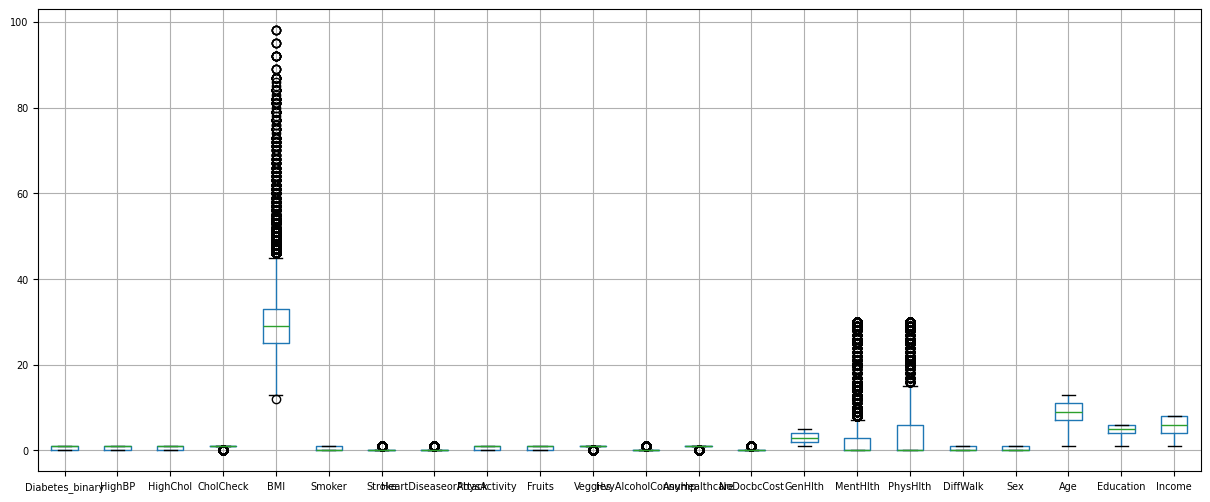

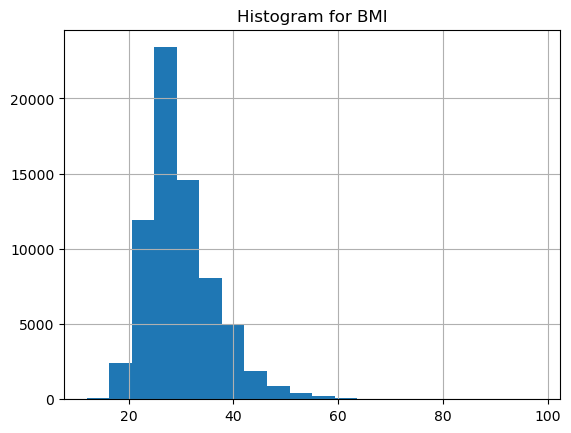

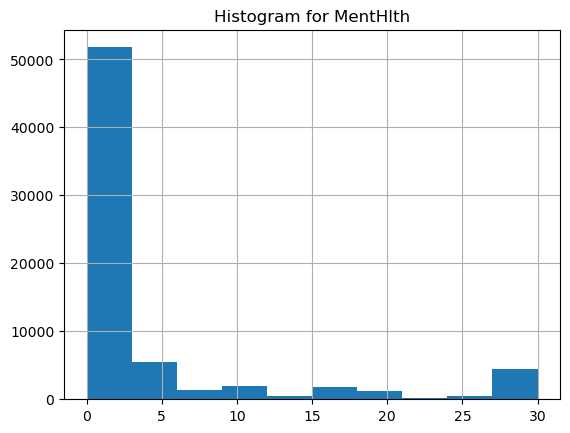

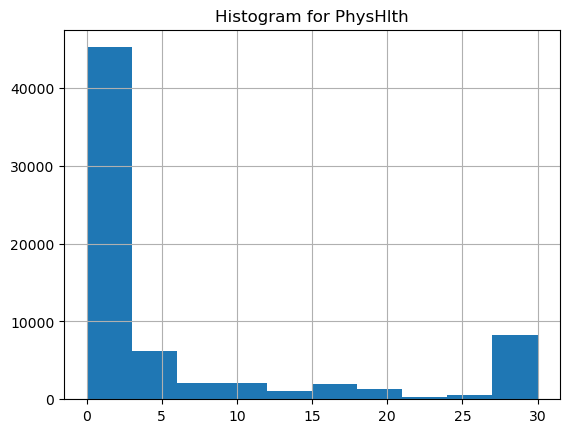

In [4]:
# Exploratory data analysis

# Drop duplicates
dups = df2.duplicated()
print("Number of duplicate rows:", dups.sum())
df2 = df2.drop_duplicates()

# Print out number of null values in each column
print("Number of null values in each column:", list(df2.isna().sum()))

# Plot a boxplot for any features with outliers
df2.boxplot(figsize=(15, 6), fontsize = 7)
plt.show()

# Histogram for BMI, MentHlth, and PhysHlth
df2['BMI'].hist(bins=20)
plt.title("Histogram for BMI")
plt.show()

df2['MentHlth'].hist(bins=10)
plt.title("Histogram for MentHlth")
plt.show()

df2['PhysHlth'].hist(bins=10)
plt.title("Histogram for PhysHlth")
plt.show()

In [5]:
# Standard Scaler for BMI
scaler = StandardScaler()
df2['BMI'] = scaler.fit_transform(pd.DataFrame(df2['BMI']))

# Discretize GenHlth, MntlHlth and PhysHlth columns
df2['MentHlth'] = pd.cut(df2['MentHlth'], bins=2, labels=[0, 1])
df2['PhysHlth'] = pd.cut(df2['PhysHlth'], bins=2, labels=[0, 1])

## Feature Selection

In [6]:
X = df2.drop(['Diabetes_binary'], axis=1)
Y = df2['Diabetes_binary']

selection = SelectKBest(mutual_info_classif)
X_transformed = pd.DataFrame(selection.fit_transform(X, Y))
X_transformed.columns = X.columns[selection.get_support()]


In [7]:
X_transformed.columns

Index(['HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'PhysActivity',
       'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Income'],
      dtype='object')

## Decision tree

In [8]:
# Base decision tree model
treeModel = DecisionTreeClassifier(criterion='entropy', random_state=0)

cross_vals = cross_validate(treeModel, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
print("Cross validation scores:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

cross_vals = cross_validate(treeModel, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
print("Cross validation scores after feature selection:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Cross validation scores:
	test_accuracy: 0.650014
	test_precision: 0.659764
	test_recall: 0.642961
	test_f1: 0.651216
Cross validation scores after feature selection:
	test_accuracy: 0.666638
	test_precision: 0.688075
	test_recall: 0.629399
	test_f1: 0.657418


In [9]:
# Find optimal tree depth for whole dataset and feature selection set
cv_accuracy = []
cv_accuracy_fs = []

for i in range(1, 15):
    decision_tree = DecisionTreeClassifier(criterion="entropy", max_depth = i, random_state=0)
    cv_accuracy.append(cross_val_score(decision_tree, X, Y).mean())
    cv_accuracy_fs.append(cross_val_score(decision_tree, X_transformed, Y).mean())
    
best_depth = cv_accuracy.index(max(cv_accuracy)) + 1
best_depth_fs = cv_accuracy_fs.index(max(cv_accuracy_fs)) + 1

print("Optimal depths for tree before and after data selection", best_depth, ',', best_depth_fs)
decision_tree = DecisionTreeClassifier(criterion="entropy", max_depth = best_depth, random_state=0)


cross_vals = cross_validate(decision_tree, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

decision_tree = DecisionTreeClassifier(criterion="entropy", max_depth = best_depth_fs, random_state=0)

cross_vals = cross_validate(decision_tree, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Optimal depths for tree before and after data selection 8 , 9
Cross validation scores:
	test_accuracy: 0.737188
	test_precision: 0.725180
	test_recall: 0.777987
	test_f1: 0.750466
Cross validation scores:
	test_accuracy: 0.736725
	test_precision: 0.724544
	test_recall: 0.777702
	test_f1: 0.750099


## Logistic Regression

In [10]:
log = LogisticRegression()
cross_vals = cross_validate(log, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores:")
for j in tests:
    print('\t%s: %f' % (j, cross_vals[j].mean()))

c:\Users\Cesar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Cesar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Cross validation scores:
	test_accuracy: 0.744125
	test_precision: 0.737793
	test_recall: 0.770323
	test_f1: 0.753663


c:\Users\Cesar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Cesar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

In [11]:
# Change max iterations to 200 (since at 100 iterations, algorithm does not converge)
print("For 200 iterations:")
log = LogisticRegression(max_iter=200)
cross_vals = cross_validate(log, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores:")
for j in tests:
    print('\t%s: %f' % (j, cross_vals[j].mean()))

cross_vals2 = cross_validate(log, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores after feature selection:")
for j in tests:
    print('\t%s: %f' % (j, cross_vals2[j].mean()))

For 200 iterations:
Cross validation scores:
	test_accuracy: 0.744240
	test_precision: 0.737809
	test_recall: 0.770637
	test_f1: 0.753821
Cross validation scores after feature selection:
	test_accuracy: 0.740432
	test_precision: 0.734725
	test_recall: 0.765793
	test_f1: 0.749883


In [12]:
# Try changing tolerance value
for i in [0.0005, 0.00001]:
    print("\nFor tolerance = %f" % i)
    log = LogisticRegression(max_iter=200, tol=i)
    cross_vals = cross_validate(log, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
    print("Cross validation scores:")
    for j in tests:
        print('\t%s: %f' % (j, cross_vals[j].mean()))

    cross_vals2 = cross_validate(log, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
    print("Cross validation scores after feature selection:")
    for j in tests:
        print('\t%s: %f' % (j, cross_vals2[j].mean()))


For tolerance = 0.000500
Cross validation scores:
	test_accuracy: 0.743907
	test_precision: 0.737750
	test_recall: 0.769753
	test_f1: 0.753368
Cross validation scores after feature selection:
	test_accuracy: 0.740331
	test_precision: 0.734749
	test_recall: 0.765422
	test_f1: 0.749718

For tolerance = 0.000010
Cross validation scores:
	test_accuracy: 0.744182
	test_precision: 0.737793
	test_recall: 0.770494
	test_f1: 0.753745
Cross validation scores after feature selection:
	test_accuracy: 0.740446
	test_precision: 0.734719
	test_recall: 0.765850
	test_f1: 0.749907


## SVC

In [13]:
# Try SVC with default (radial basis function), then cross validation.
svm = SVC(random_state=0)
cross_vals = cross_validate(svm, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
print("Cross validation scores:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Cross validation scores:
	test_accuracy: 0.748092
	test_precision: 0.719379
	test_recall: 0.826966
	test_f1: 0.769373


In [14]:
cross_vals = cross_validate(svm, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
print("Cross validation scores after feature selection:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Cross validation scores after feature selection:
	test_accuracy: 0.742836
	test_precision: 0.714723
	test_recall: 0.822236
	test_f1: 0.764668


In [15]:
# Try with linear kernel function
print("Using the linear kernel function,")
svm = SVC(kernel='linear', random_state=0)
cross_vals = cross_validate(svm, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
print("Cross validation scores:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))
cross_vals = cross_validate(svm, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
print("Cross validation scores after feature selection:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Using the linear kernel function,
Cross validation scores:
	test_accuracy: 0.744168
	test_precision: 0.728255
	test_recall: 0.792262
	test_f1: 0.758868
Cross validation scores after feature selection:
	test_accuracy: 0.740070
	test_precision: 0.724448
	test_recall: 0.788501
	test_f1: 0.755077


In [16]:
# Try with polynomial kernel function
print("Using the polynomial kernel function,")
svm = SVC(kernel='poly', random_state=0)
cross_vals = cross_validate(svm, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
print("Cross validation scores:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

cross_vals = cross_validate(svm, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
print("Cross validation scores after feature selection:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Using the polynomial kernel function,
Cross validation scores:
	test_accuracy: 0.748483
	test_precision: 0.731144
	test_recall: 0.798844
	test_f1: 0.763455
Cross validation scores after feature selection:
	test_accuracy: 0.741301
	test_precision: 0.744805
	test_recall: 0.746959
	test_f1: 0.745814


## KNN

In [17]:
# Base KNN (default arguments)
knn = KNeighborsClassifier()

print("Before feature selection:")
cross_vals = cross_validate(knn, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

print("\nAfter feature selection:")
cross_vals = cross_validate(knn, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'])
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Before feature selection:
	test_accuracy: 0.702738
	test_precision: 0.709249
	test_recall: 0.703479
	test_f1: 0.706321

After feature selection:
	test_accuracy: 0.703187
	test_precision: 0.717498
	test_recall: 0.686242
	test_f1: 0.701443


In [18]:
# Testing out with different values for n_neighbours
k = [11, 21, 31, 51, 75]
for i in k:
    knn = KNeighborsClassifier(n_neighbors=i)
    print("\nFor %d neighbours: " % i)

    print("Cross validation scores:")
    cross_val = cross_validate(knn, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv = 10)
    for i in tests:
        print('\t%s: %f' % (i, cross_val[i].mean()))

    print("Cross validation scores after feature selection:")
    cross_val = cross_validate(knn, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv = 10)
    for i in tests:
        print('\t%s: %f' % (i, cross_val[i].mean()))


For 11 neighbours: 
Cross validation scores:
	test_accuracy: 0.722331
	test_precision: 0.718820
	test_recall: 0.745079
	test_f1: 0.731672
Cross validation scores after feature selection:
	test_accuracy: 0.724098
	test_precision: 0.724548
	test_recall: 0.737585
	test_f1: 0.730944

For 21 neighbours: 
Cross validation scores:
	test_accuracy: 0.732323
	test_precision: 0.722029
	test_recall: 0.769583
	test_f1: 0.744984
Cross validation scores after feature selection:
	test_accuracy: 0.731772
	test_precision: 0.724376
	test_recall: 0.762288
	test_f1: 0.742792

For 31 neighbours: 
Cross validation scores:
	test_accuracy: 0.735407
	test_precision: 0.722307
	test_recall: 0.778786
	test_f1: 0.749430
Cross validation scores after feature selection:
	test_accuracy: 0.735870
	test_precision: 0.724732
	test_recall: 0.774512
	test_f1: 0.748739

For 51 neighbours: 
Cross validation scores:
	test_accuracy: 0.740924
	test_precision: 0.725071
	test_recall: 0.789670
	test_f1: 0.755921
Cross validation s

## Random Forest

In [19]:
# Testing random forest
forest = RandomForestClassifier(max_depth=8, random_state=0)
cross_vals = cross_validate(forest, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

cross_vals = cross_validate(forest, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores after feature selection:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Cross validation scores:
	test_accuracy: 0.744559
	test_precision: 0.727750
	test_recall: 0.794741
	test_f1: 0.759699
Cross validation scores after feature selection:
	test_accuracy: 0.743589
	test_precision: 0.727145
	test_recall: 0.793174
	test_f1: 0.758655


In [20]:
# Trying random forest with n_estimators = 50 (number of trees)
forest = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=0)

cross_vals = cross_validate(forest, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores with n_estimators = 50:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

cross_vals = cross_validate(forest, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores after feature selection:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Cross validation scores with n_estimators = 50:
	test_accuracy: 0.744588
	test_precision: 0.728256
	test_recall: 0.793602
	test_f1: 0.759458
Cross validation scores after feature selection:
	test_accuracy: 0.743951
	test_precision: 0.727165
	test_recall: 0.794228
	test_f1: 0.759152


In [21]:
# Finding optimal depth of tree in random forest
cv_accuracy = []
cv_accuracy_fs = []

for i in range(1, 15):
    forest = RandomForestClassifier(n_estimators = 50, criterion="entropy", max_depth = i, random_state=0)
    cv_accuracy.append(cross_val_score(forest, X, Y).mean())
    cv_accuracy_fs.append(cross_val_score(forest, X_transformed, Y).mean())
    
best_depth = cv_accuracy.index(max(cv_accuracy)) + 1
best_depth_fs = cv_accuracy_fs.index(max(cv_accuracy_fs)) + 1

print("Optimal depths for tree before and after data selection", best_depth, ',', best_depth_fs)
best_forest = RandomForestClassifier(n_estimators = 100, criterion="entropy", max_depth = best_depth, random_state=0)

# print("\nAccuracy before feature selection:", cv_accuracy[best_depth])
cross_vals = cross_validate(best_forest, X, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

forest_fs = RandomForestClassifier(n_estimators = 50, criterion="entropy", max_depth = best_depth_fs, random_state=0)
# print("\nAccuracy after feature selection:", cv_accuracy_fs[best_depth_fs])
cross_vals = cross_validate(forest_fs, X_transformed, Y, scoring = ['accuracy', 'precision', 'recall', 'f1'], cv=10)
print("Cross validation scores:")
for i in tests:
    print('\t%s: %f' % (i, cross_vals[i].mean()))

Optimal depths for tree before and after data selection 12 , 9
Cross validation scores:
	test_accuracy: 0.747209
	test_precision: 0.730505
	test_recall: 0.796479
	test_f1: 0.762009
Cross validation scores:
	test_accuracy: 0.743820
	test_precision: 0.727322
	test_recall: 0.793430
	test_f1: 0.758882
